. SMS Spam Collection Dataset
This dataset contains a collection of SMS messages labeled as spam or ham (non-spam).
As a data scientist in a telecom company, you are required to build an intelligent SMS filtering system to classify incoming messages automatically.
a. Apply data preprocessing (text cleaning, tokenization, label encoding, TF–IDF vectorization).
b. Perform data preparation (train–test split).
c. Apply Naive Bayes classifier (MultinomialNB / BernoulliNB) to predict spam messages.
d. Evaluate model performance using accuracy, precision, recall, and F1-score.
e. Apply cross-validation and analyze model robustness.



import pandas as pd

In [75]:
import pandas as pd
#vpandas → to load and handle data (like Excel tables).


In [76]:
'''Reads the file spam.csv which contains text messages.
The dataset is tab-separated (\t), not comma-separated, so we specify sep='\t'.
We rename columns as label (spam/ham) and message (SMS text).df.head() shows the first few rows.'''

# Reload dataset correctly (tab-separated)
df = pd.read_csv("/content/Navy Bays_SMS SpamCollection.CSV", sep='\t', header=None, names=['label', 'message'], encoding='latin-1')

# Display first few rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [77]:
# Encode text labels into numerical format
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Check distribution



In [78]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [79]:
df['label'].value_counts()


,count
label,
0,4825
1,747


In [80]:
# Convert text messages into numerical features using TF-IDF
# TfidfVectorizer → to convert text messages into numbers.

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english') # remove common words

# Independent variable (X) and Target variable (y)
X = tfidf.fit_transform(df['message'])
y = df['label']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (5572, 8480)
Shape of y: (5572,)


In [96]:
# Split the dataset into training and testing parts
'''Divides the dataset into:
Training data (80%) → used to train the model
Testing data (20%) → used to test the model’s accuracy
random_state=42 ensures the same split every time you run it.'''
from sklearn.model_selection import train_test_split, cross_val_score

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)
print("Training samples:", y_train.shape)
print("Testing samples:", y_test.shape)

Training samples: (4457, 8480)
Testing samples: (1115, 8480)
Training samples: (4457,)
Testing samples: (1115,)


In [82]:
# Initialize and train the Multinomial Naive Bayes model
# MultinomialNB → Naive Bayes algorithm for text classification.
'''Creates a Multinomial Naive Bayes model — best for text classification problems.
fit() trains the model on training data (X_train, y_train).'''
from sklearn.naive_bayes import MultinomialNB

model_m = MultinomialNB()
model_m.fit(X_train, y_train)


MultinomialNB()

In [83]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score



In [84]:
model_bernoulli = BernoulliNB()
model_bernoulli.fit(X_train, y_train)


BernoulliNB()

In [97]:
y_pred_b = model_bernoulli.predict(X_test)

print("BernoulliNB Accuracy:", {accuracy_score(y_test, y_pred_b)})

BernoulliNB Accuracy: {0.979372197309417}


In [86]:
# Predict labels for test data
'''Uses the trained model to predict whether each test message is spam or ham.Stores predictions in y_pred.'''
y_pred = model_m.predict(X_test)


# Display few predictions
#1st way :
# y_pred[:100]

#2nd way :
# print("Sample Predictions:", y_pred[:200]) #you can also write y_pred  only
# simplest  way
y_pred


array([0, 0, 0, ..., 0, 0, 0])

In [98]:
y_pred_b = model_bernoulli.predict(X_test)

print("MultinomialNBAccuracy:", {accuracy_score(y_test, y_pred)})

MultinomialNBAccuracy: {0.979372197309417}


In [87]:
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay


Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.85      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



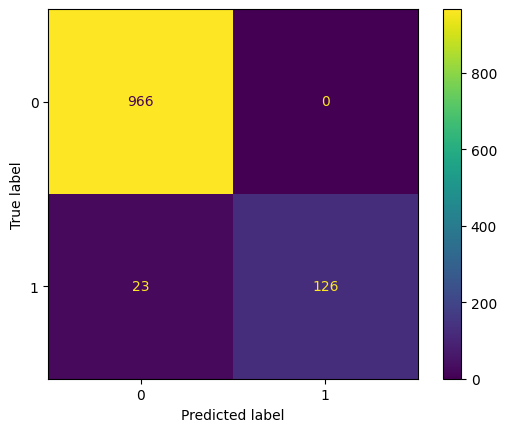

In [88]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

# Print classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       966
           1       0.96      0.88      0.92       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



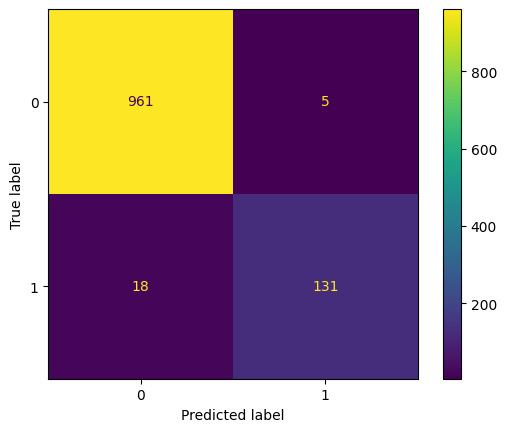

In [89]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_b)
# Print classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred_b))

In [90]:
# Perform 5-fold cross-validation
'''Performs 5-fold cross-validation (dataset split into 5 parts).
Trains and tests model 5 times on different splits.
cv_scores.mean() → average accuracy across all 5 folds.
Helps check if the model is stable and not just lucky on one split.'''

cv_scores = cross_val_score(model_m, X, y, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.97847534 0.96681614 0.96319569 0.97127469 0.97217235]
Average CV Accuracy: 0.970386841745095


In [91]:

cv_scores = cross_val_score(model_bernoulli, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.9838565  0.97309417 0.97307002 0.97396768 0.97935368]
Average CV Accuracy: 0.976668411010297


In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming your predictions are y_pred and true labels are y_test
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# If you did cross-validation before
cv_acc = cv_scores.mean()  # make sure cv_scores exists


In [93]:
# Create a summary DataFrame for quick reference
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Cross-Val Accuracy'],
    'Score': [acc, prec, rec, f1, cv_scores.mean()]
})
summary


,Metric,Score
0,Accuracy,0.979372
1,Precision,1.000000
2,Recall,0.845638
3,F1 Score,0.916364
4,Cross-Val Accuracy,0.976668


In [94]:
new_messages = [
    "Congratulations! You have won a $500 Amazon gift card. Click here to claim.",
    "Hey, are we still meeting for lunch today?"
]
for msg in new_messages:
    pred = model_m.predict(tfidf.transform([msg]))[0]
    print(msg, "-->", "spam" if pred else "ham")


Congratulations! You have won a $500 Amazon gift card. Click here to claim. --> spam
Hey, are we still meeting for lunch today? --> ham


In [95]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
params = {'C':[1,10]}   # just 2 options

grid = GridSearchCV(LogisticRegression(), params, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)


{'C': 10}
0.9697102624872925
